In [1]:
#     101a_resonator_spectroscopy
# 
#     Gun Suer
#     June 25, 2026

In [2]:
# Import the QICK drivers and auxiliary libraries
from qick import *
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [3]:
# Load bitstream with custom overlay
soc = QickSoc()
# Since we're running locally on the QICK, we don't need a separate QickConfig object.
# If running remotely, you could generate a QickConfig from the QickSoc:
#     soccfg = QickConfig(soc.get_cfg())
# or save the config to file, and load it later:
#     with open("qick_config.json", "w") as f:
#         f.write(soc.dump_cfg())
#     soccfg = QickConfig("qick_config.json")
soccfg = soc
print(soccfg)

GEN_CH = 3
RO_CH = 1

QICK running on RFSoC2x4, software version 0.2.393

Firmware configuration (built Sun Mar 15 22:07:33 2026):

	Global clocks (MHz): tProc dispatcher timing 409.600, RF reference 491.520
	Groups of related clocks: [tProc clock, DAC tile 0, DAC tile 2], [ADC tile 0, ADC tile 2]

	DAC output power mode: 20mA

	4 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 0 is DAC_D
	1:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 2 is DAC_C
	2:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is DAC_B
	3:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=

In [7]:
class Program(AveragerProgram):
    def initialize(self):
        cfg=self.cfg   
        res_ch = cfg["res_ch"]

        # set the nyquist zone
        self.declare_gen(ch=cfg["res_ch"], nqz=1)
        
        # configure the readout lengths and downconversion frequencies (ensuring it is an available DAC frequency)
        for ch in cfg["ro_chs"]:
            self.declare_readout(ch=ch, length=self.cfg["readout_length"],
                                 freq=self.cfg["pulse_freq"], gen_ch=cfg["res_ch"])

        # convert frequency to DAC frequency (ensuring it is an available ADC frequency)
        freq = self.freq2reg(cfg["pulse_freq"],gen_ch=res_ch, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]
        self.default_pulse_registers(ch=res_ch, freq=freq, phase=phase, gain=gain)

        style=self.cfg["pulse_style"]

        if style in ["flat_top","arb"]:
            sigma = cfg["sigma"]
            self.add_gauss(ch=res_ch, name="measure", sigma=sigma, length=sigma*5)
            
        if style == "const":
            self.set_pulse_registers(ch=res_ch, style=style, length=cfg["length"])
        elif style == "flat_top":
            # The first half of the waveform ramps up the pulse, the second half ramps down the pulse
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure", length=cfg["length"])
        elif style == "arb":
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure")
        
        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        # fire the pulse
        # trigger all declared ADCs
        # pulse PMOD0_0 for a scope trigger
        # pause the tProc until readout is done
        # increment the time counter to give some time before the next measurement
        # (the syncdelay also lets the tProc get back ahead of the clock)
        self.measure(pulse_ch=self.cfg["res_ch"], 
                     adcs=self.ro_chs,
                     pins=[0], 
                     adc_trig_offset=self.cfg["adc_trig_offset"],
                     wait=True,
                     syncdelay=self.us2cycles(self.cfg["relax_delay"]))
        
        # equivalent to the following:
#         self.trigger(adcs=self.ro_chs,
#                      pins=[0], 
#                      adc_trig_offset=self.cfg["adc_trig_offset"])
#         self.pulse(ch=self.cfg["res_ch"])
#         self.wait_all()
#         self.sync_all(self.us2cycles(self.cfg["relax_delay"]))

In [114]:
config={"res_ch":GEN_CH, # --Fixed
        "ro_chs":[RO_CH], # --Fixed
        "reps":1, # --Fixed
        "relax_delay":1.0, # --us
        "res_phase":0, # --degrees
        "pulse_style": "const", # --Fixed
        
        "length":240, # [Clock ticks]
        # Try varying length from 10-100 clock ticks
        
        "readout_length":200, # [Clock ticks]
        # Try varying readout_length from 50-1000 clock ticks

        "pulse_gain":30_000, # [DAC units]
        # Try varying pulse_gain from 500 to 30000 DAC units

        "pulse_freq": 20, # [MHz]
        # In this program the signal is up and downconverted digitally so you won't see any frequency
        # components in the I/Q traces below. But since the signal gain depends on frequency, 
        # if you lower pulse_freq you will see an increased gain.

        "adc_trig_offset": 170, # [Clock ticks]
        # Try varying adc_trig_offset from 100 to 220 clock ticks

        "soft_avgs":50
        # Try varying soft_avgs from 1 to 200 averages

       }

In [115]:
prog = Program(soccfg, config)
iq_list = prog.acquire_decimated(soc, progress=True)

  0%|          | 0/50 [00:00<?, ?it/s]

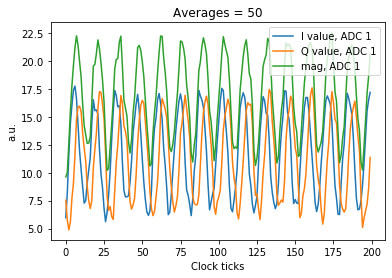

In [116]:
# Plot results.
plt.figure(1)
for ii, iq in enumerate(iq_list):
    plt.plot(iq[0], label="I value, ADC %d"%(config['ro_chs'][ii]))
    plt.plot(iq[1], label="Q value, ADC %d"%(config['ro_chs'][ii]))
    plt.plot(np.abs(iq[0]+1j*iq[1]), label="mag, ADC %d"%(config['ro_chs'][ii]))
plt.ylabel("a.u.")
plt.xlabel("Clock ticks")
plt.title("Averages = " + str(config["soft_avgs"]))
plt.legend();

In [117]:
config

{'res_ch': 3,
 'ro_chs': [1],
 'reps': 1,
 'relax_delay': 1.0,
 'res_phase': 0,
 'pulse_style': 'const',
 'length': 240,
 'readout_length': 200,
 'pulse_gain': 30000,
 'pulse_freq': 20,
 'adc_trig_offset': 170,
 'soft_avgs': 50}

In [118]:
LO_frequency = 4000  # MHz
res_frequency = 4011 # MHz

res_spec_span = 100 # MHz
res_spec_df = 0.5 # MHz

res_spec_sweep_dfs = np.arange(
    -res_spec_span/2,
    res_spec_span/2 + res_spec_df,
    res_spec_df
)

res_spec_frequency = res_spec_sweep_dfs + res_frequency

In [119]:
# Storage arrays
I_data = np.zeros(len(res_spec_frequency))
Q_data = np.zeros(len(res_spec_frequency))

for i, f_rf in enumerate(res_spec_frequency):

    # IF frequency seen by the QICK
    f_if = f_rf - LO_frequency

    cfg = config.copy()
    cfg["pulse_freq"] = f_if

    prog = Program(soccfg, cfg)

    avgi, avgq = prog.acquire(soc)

    I_data[i] = avgi[0][0]
    Q_data[i] = avgq[0][0]

#     if i % 100 == 0:
#         print(f"{i}/{len(res_spec_frequency)} : RF = {f_rf:.3f} MHz")

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [120]:
amp = np.sqrt(I_data**2 + Q_data**2)
phase = np.unwrap(np.arctan2(Q_data, I_data))

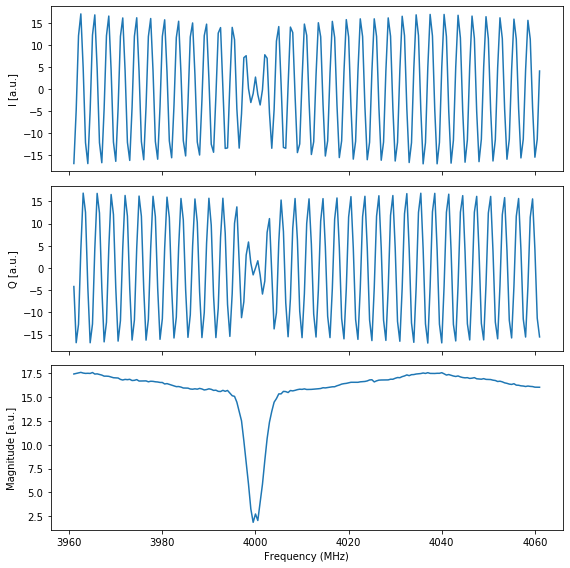

In [121]:
fig, ax = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

ax[0].plot(res_spec_frequency, I_data)
ax[0].set_ylabel("I [a.u.]")

ax[1].plot(res_spec_frequency, Q_data)
ax[1].set_ylabel("Q [a.u.]")

ax[2].plot(res_spec_frequency, amp)
ax[2].set_ylabel("Magnitude [a.u.]")
ax[2].set_xlabel("Frequency (MHz)")

plt.tight_layout()
plt.show()

In [122]:
from scipy.io import savemat

savemat("K001_20260625_wide_res_scan.mat", {
    "frequency": res_spec_frequency,
    "I": I_data,
    "Q": Q_data,
})